<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Solar Diagnostic 1 - Solar I/O and Profile
---

This notebook diagnoses the solar data-loading, profile, and adiabatic matter-mixing layers: `tpeanuts.medium.solar.io`, `tpeanuts.medium.solar.profile`, and `tpeanuts.medium.solar.matter_mixing`. The automated tests live in `tpeanuts.medium.solar.test.test1_io`, `test2_profile`, and `test3_adiabatic`; here we keep visual checks for the loaded B16/Zenodo solar model, source production profiles, source fluxes, spectra, solar-coordinate conversions, matter mixing functions, Landau-Zener resonance diagnostics, and Sun-Earth distance table.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: solar model tables, production profiles, and flux inputs |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Solar-Model-I/O) | **Solar Model I/O**: loaded radius, density, and source tables |
| [4](#4.-SolarProfile) | **SolarProfile**: interpolation, normalized production, cumulative profiles |
| [5](#5.-Fluxes-and-Spectra) | **Fluxes and Spectra**: source normalizations and tabulated spectra |
| [6](#6.-Solar-Coordinates) | **Solar Coordinates** |
| [7](#7.-Adiabatic-Matter-Mixing) | **Adiabatic Matter Mixing** |
| [8](#8.-Landau-Zener-Correction) | **Landau-Zener Correction** |
| [9](#9.-Sun-Earth-Distance) | **Sun-Earth Distance** |
| [?](#10.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Solar Profile Inputs

The solar medium layer uses tabulated profiles as input data. The primary radial coordinate is

$$
\rho = \frac{r}{R_\odot},
\qquad 0 \le \rho \le 1,
$$

and the electron density $n_e(\rho)$ is stored in mol cm$^{-3}$. In the CSV layout, the density is provided as $\log_{10}(n_e)$ and converted to linear scale by the I/O layer.

### 0.2 Production Fractions

For each solar neutrino source $s$, the model stores a radial production profile $f_s(\rho)$. The raw table is not assumed to be normalized. The profile layer defines

$$
\hat f_s(\rho)=\frac{f_s(\rho)}{\int f_s(\rho)\,d\rho},
$$

so diagnostic integrals and cumulative distributions can be compared consistently between sources.

### 0.3 Source Fluxes and Spectra

The flux table gives total source fluxes $\Phi_s$. Optional source spectra $g_s(E)$ provide energy-dependent weights. Downstream solar-flux calculations combine source probabilities, total source fluxes, and spectra, but this notebook focuses only on verifying that these inputs are loaded, finite, and shaped correctly.

### 0.4 Solar Coordinates

The solar model radius is the dimensionless coordinate $\rho=r/R_\odot$. Coherent solar propagation often converts this coordinate into a physical radial distance,

$$
r = \rho R_\odot,
\qquad
L(\rho_0\to1)=(1-\rho_0)R_\odot.
$$

A profile-aligned path grid starts at the production radius $\rho_0$, follows the tabulated profile radii above that point, and ends at the solar surface.

### 0.5 Adiabatic Matter Mixing

In matter, coherent forward scattering on electrons modifies the effective mixing angles that enter the solar MSW adiabatic approximation. The module `medium.solar.matter_mixing` evaluates the dimensionless matter-to-kinetic ratio

$$
V_k(\Delta m^2, E, n_e)=\frac{2E\,\hbar c\,V_{CC}(n_e)}{\Delta m^2},
$$

and the effective atmospheric splitting

$$
\Delta m^2_{ee}=\cos^2\theta_{12}\,\Delta m^2_{31}
+\sin^2\theta_{12}\,\Delta m^2_{32}.
$$

The matter-modified angles are then computed analytically as

$$
\theta^M_{13}=\frac{1}{2}\arccos
\left[
\frac{\cos 2\theta_{13}-V_k(\Delta m^2_{ee})}
{\sqrt{(\cos 2\theta_{13}-V_k(\Delta m^2_{ee}))^2+\sin^2 2\theta_{13}}}
\right],
$$

and

$$
\theta^M_{12}=\frac{1}{2}\arccos
\left[
\frac{\cos 2\theta_{12}-V'_k}
{\sqrt{(\cos 2\theta_{12}-V'_k)^2+\sin^2 2\theta_{12}\cos^2(\theta^M_{13}-\theta_{13})}}
\right],
$$

with

$$
V'_k=V_k(\Delta m^2_{21})\cos^2\theta^M_{13}
+\frac{\Delta m^2_{ee}}{\Delta m^2_{21}}\sin^2(\theta^M_{13}-\theta_{13}).
$$

These expressions are the analytic input used by the adiabatic production weights $T_{ei}$ in the standard solar-probability path.

### 0.6 Landau-Zener Correction

The adiabatic approximation assumes that a neutrino remains on the same instantaneous matter eigenstate while the density changes. Near the MSW resonance, finite adiabaticity can induce a jump between the first two matter eigenstates. In the exponential Parke approximation,

$$
P_{LZ}(E)=\exp\left[-\frac{\pi}{2}\gamma_{res}(E)\right],
$$

where the resonance is defined by

$$
V_k(\Delta m^2_{21},E,n_e(r_{res}))=\cos 2\theta_{12},
$$

and

$$
\gamma_{res}=\frac{\Delta m^2_{21}\sin^2 2\theta_{12}}
{2E\,\hbar c\,\cos 2\theta_{12}}\,L_n(r_{res}),
\qquad
L_n=\left|\frac{n_e}{dn_e/dl}\right|_{r_{res}}.
$$

For standard LMA solar parameters, $\gamma_{res}$ is very large and $P_{LZ}$ is numerically zero in double precision for the usual solar-neutrino range. The diagnostic is still useful to verify the resonance location, masking of no-resonance energies, and the interface used by `solar_probability_mass` when `profile.use_LZ` is enabled.

### 0.7 Sun-Earth Distance

The date-resolved Sun-Earth distance table supports time-dependent solar baseline calculations. The orbital distance varies by a few percent annually and can affect flux normalizations through inverse-square scaling in downstream analyses.

### References

- N. Vinyoles et al., *A new Generation of Standard Solar Models*, Astrophysical Journal 835, 202 (2017).
- J. N. Bahcall, A. M. Serenelli, and S. Basu, solar model and neutrino flux tabulations used by the legacy B16-style inputs.

## 1. Libraries

All imports are centralized here. The notebook uses only the packaged solar tables and shared notebook helpers.

In [21]:
from __future__ import annotations

from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.solar.landau_zener import density_gradient, plz, resonance_radius
from tpeanuts.medium.solar.matter_mixing import DeltamSqee, Vk, th12_M, th13_M
from tpeanuts.medium.solar.probability import Tei
from tpeanuts.medium.solar.io import (
    default_solar_data_dir,
    load_b16_fluxes,
    load_b16_solar_model,
    load_spectrum_csv,
    load_sun_earth_distance,
)
from tpeanuts.medium.solar.profile import SolarProfile, build_solar_profile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.util.constant import R_SUN_KM
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

The output directory follows the notebook relative location below `notebooks/`: diagnostic figures from this notebook are saved under `diagnostic/solar`.

In [22]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "solar")
SHOW_PLOTS = config.show_plots
SOLAR_DATA_DIR = default_solar_data_dir()
SPECTRA_DIR = SOLAR_DATA_DIR / "spectra"

print(f"Repository root: {config.package_dir}")
print(f"Solar data directory: {SOLAR_DATA_DIR}")
print(f"Figure output directory: {OUTPUT_DIR}")

Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Solar data directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar
Figure output directory: v:\output\diagnostic\solar


### 2.2 Configuration

The notebook loads the default solar profile selected by `tpeanuts.config.default`, currently a Zenodo SF3-AGSS09 profile in the B16-compatible CSV layout. A small list of representative sources is used for overlaid plots. The adiabatic matter-mixing diagnostics use the `_SM_NUFIT52_NO` oscillation preset and representative solar-neutrino energies of 0.1, 1, 5, and 10 MeV.

**Expected results**: the radius grid should be one-dimensional and increasing, electron density should be finite and positive, source fractions should be finite, and normalized production profiles should integrate to one.

In [23]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
PROFILE = build_solar_profile(None, context=ctx)
MODEL = load_b16_solar_model(device=ctx.device, dtype=ctx.dtype)
FLUXES = load_b16_fluxes(device=ctx.device, dtype=ctx.dtype)
DISTANCE = load_sun_earth_distance(device=ctx.device, dtype=ctx.dtype)
OSCILLATION = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", context=ctx)
MIXING_ENERGIES_MEV = torch.tensor([0.1, 1.0, 5.0, 10.0], device=ctx.device, dtype=ctx.dtype)
LZ_ENERGIES_MEV = torch.logspace(-1.0, torch.log10(torch.tensor(20.0, device=ctx.device, dtype=ctx.dtype)), 160, device=ctx.device, dtype=ctx.dtype)

PLOT_SOURCES = [source for source in ["pp", "pep", "7Be", "8B", "13N", "15O", "17F", "hep"] if source in PROFILE.fractions]
SPECTRUM_FILES = {
    "pp": SPECTRA_DIR / "spectrum_pp.csv",
    "7Be": SPECTRA_DIR / "spectrum_7Be.csv",
    "8B": SPECTRA_DIR / "spectrum_8B.csv",
    "hep": SPECTRA_DIR / "spectrum_hep.csv",
}
SPECTRUM_FILES = {source: path for source, path in SPECTRUM_FILES.items() if path.exists()}

print(f"SolarProfile: n_r={PROFILE.radius.numel()}, r=[{float(PROFILE.radius[0]):.3f}, {float(PROFILE.radius[-1]):.3f}], density=[{float(PROFILE.density.min()):.3e}, {float(PROFILE.density.max()):.3e}], device={PROFILE.device}, dtype={PROFILE.dtype}")
print("sources in profile:", sorted(PROFILE.fractions))
print("sources in flux table:", sorted(PROFILE.fluxes))
print("spectra used:", {key: str(value.name) for key, value in SPECTRUM_FILES.items()})
print("oscillation preset:", OSCILLATION.preset_name, OSCILLATION.ordering)
print("mixing diagnostic energies [MeV]:", to_numpy(MIXING_ENERGIES_MEV))
print("Landau-Zener energy range [MeV]:", float(LZ_ENERGIES_MEV[0]), float(LZ_ENERGIES_MEV[-1]))

SolarProfile: n_r=2000, r=[0.001, 1.000], density=[2.352e-11, 1.007e+02], device=cpu, dtype=torch.float64
sources in profile: ['13N', '15O', '17F', '7Be', '8B', 'hep', 'pep', 'pp']
sources in flux table: ['13N', '15O', '17F', '7Be', '8B', 'hep', 'pep', 'pp']
spectra used: {'pp': 'spectrum_pp.csv', '7Be': 'spectrum_7Be.csv', '8B': 'spectrum_8B.csv', 'hep': 'spectrum_hep.csv'}
oscillation preset: _SM_NUFIT52_NO NO
mixing diagnostic energies [MeV]: [ 0.1  1.   5.  10. ]


### 2.3 Local Helpers

Small helpers keep the plotting cells focused on the diagnostic quantity being shown.

In [24]:
def trapz_area(y, x):
    return torch.trapz(y, x=x)


def cumulative_trapz(y, x):
    dx = x[1:] - x[:-1]
    increments = 0.5 * (y[1:] + y[:-1]) * dx
    return torch.cat([torch.zeros(1, device=x.device, dtype=x.dtype), torch.cumsum(increments, dim=0)])


def median_radius(normalized_fraction, radius):
    cdf = cumulative_trapz(normalized_fraction, radius)
    index = torch.searchsorted(cdf, torch.tensor(0.5, device=radius.device, dtype=radius.dtype)).clamp(max=radius.numel() - 1)
    return radius[index]

## 3. Solar Model I/O

### 3.1 Radius Grid and Electron Density

This plot shows the loaded electron-density profile in linear scale.

**Expected results**: density should be positive, finite, and decrease strongly from the solar core toward the surface.

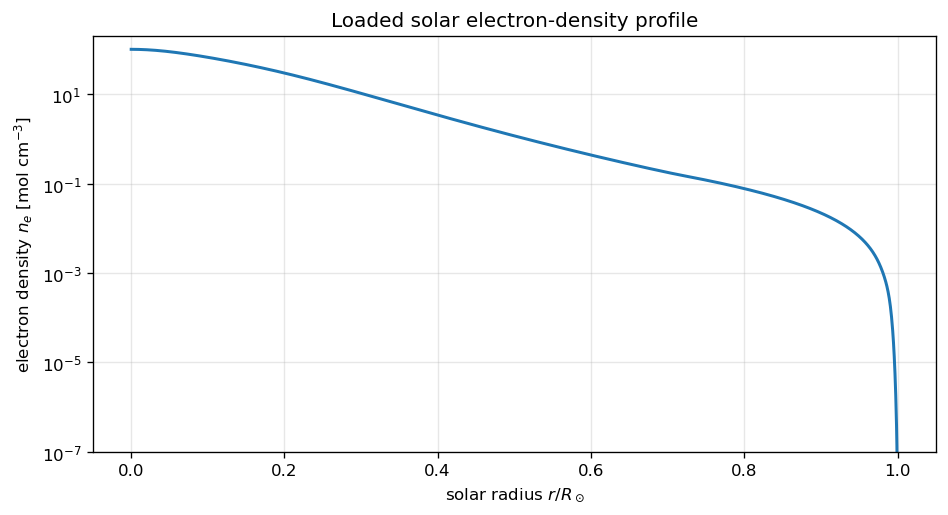

v:\output\diagnostic\solar\diagnostic1_solar_fig3_1_electron_density.png
radius shape: (2000,)
density min/max: 2.352339493388943e-11 100.71403596013589
radius monotonic increasing: True


In [25]:
radius = PROFILE.radius
density = PROFILE.density

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.semilogy(to_numpy(radius), to_numpy(density), lw=1.8)
ax.set_xlabel(r"solar radius $r/R_\odot$")
ax.set_ylabel(r"electron density $n_e$ [mol cm$^{-3}$]")
ax.set_title("Loaded solar electron-density profile")
ax.set_ylim(1e-7,2e2)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig3_1_electron_density.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("radius shape:", tuple(radius.shape))
print("density min/max:", float(density.min()), float(density.max()))
print("radius monotonic increasing:", bool(torch.all(torch.diff(radius) > 0.0)))

### 3.2 Raw Production Fractions

The raw source profiles are loaded directly from the solar model table.

**Expected results**: profiles should be finite and concentrated mostly in the solar interior, with source-dependent radial support.

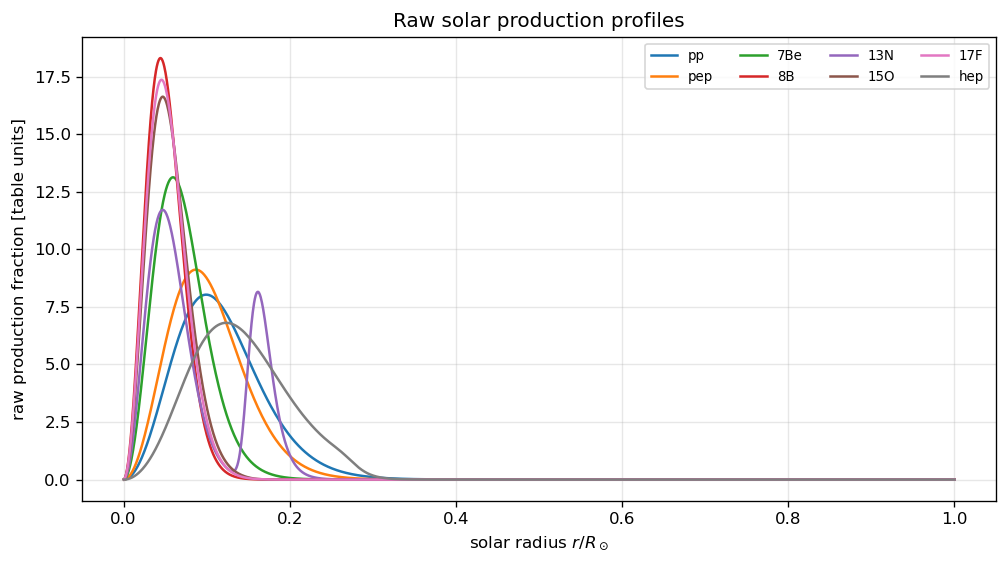

v:\output\diagnostic\solar\diagnostic1_solar_fig3_2_raw_production_profiles.png
raw trapz areas: {'pp': 0.999999806851076, 'pep': 0.999999714195646, '7Be': 0.9999992732975335, '8B': 0.9999979816269065, '13N': 0.9999987589568412, '15O': 0.9999985778778483, '17F': 0.9999978109064466, 'hep': 0.999999920191184}


In [26]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for source in PLOT_SOURCES:
    values = PROFILE.production_fraction(source)
    ax.plot(to_numpy(radius), to_numpy(values), lw=1.5, label=source)
ax.set_xlabel(r"solar radius $r/R_\odot$")
ax.set_ylabel("raw production fraction [table units]")
ax.set_title("Raw solar production profiles")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig3_2_raw_production_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

areas = {source: float(trapz_area(PROFILE.production_fraction(source), radius).detach().cpu()) for source in PLOT_SOURCES}
print("raw trapz areas:", areas)

## 4. SolarProfile

### 4.1 Interpolated Density Check

`SolarProfile.electron_density` interpolates the tabulated density onto arbitrary query radii. Edge queries are clamped to the tabulated edge values.

**Expected results**: interpolated values should follow the tabulated profile and remain finite/positive.

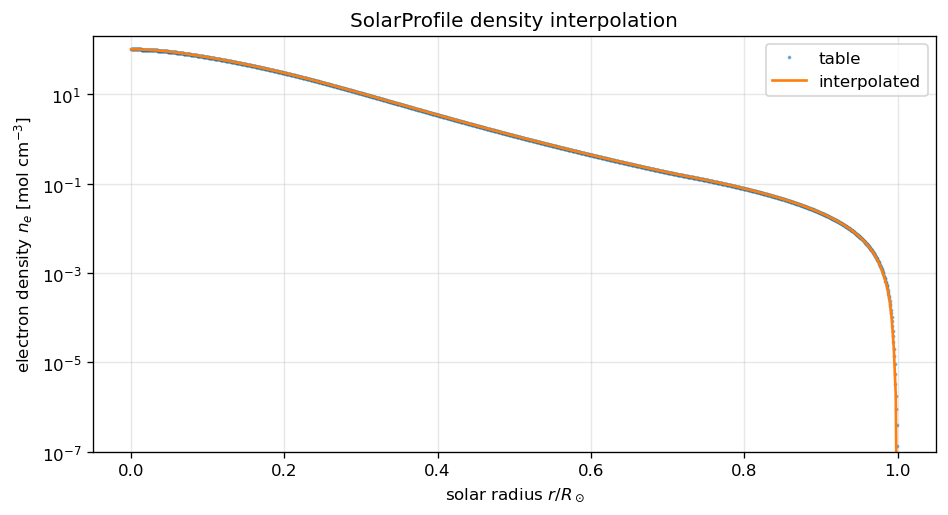

v:\output\diagnostic\solar\diagnostic1_solar_fig4_1_density_interpolation.png
interpolated density finite: True
interpolated density min/max: 2.3523394933890344e-11 100.71403596013589


In [40]:
r_query = torch.linspace(float(radius[0]), float(radius[-1]), 400, device=ctx.device, dtype=ctx.dtype)
density_query = PROFILE.electron_density(r_query)

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.semilogy(to_numpy(radius), to_numpy(density), ".", ms=2.5, alpha=0.5, label="table")
ax.semilogy(to_numpy(r_query), to_numpy(density_query), lw=1.6, label="interpolated")
ax.set_xlabel(r"solar radius $r/R_\odot$")
ax.set_ylabel(r"electron density $n_e$ [mol cm$^{-3}$]")
ax.set_title("SolarProfile density interpolation")
ax.legend()
ax.set_ylim(1e-7,2e2)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig4_1_density_interpolation.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("interpolated density finite:", bool(torch.isfinite(density_query).all()))
print("interpolated density min/max:", float(density_query.min()), float(density_query.max()))

### 4.2 Normalized Production Profiles

The normalized production fraction integrates to one over the radius grid for each source.

**Expected results**: each curve should be non-negative and the numerical trapezoidal area should be one within floating-point precision.

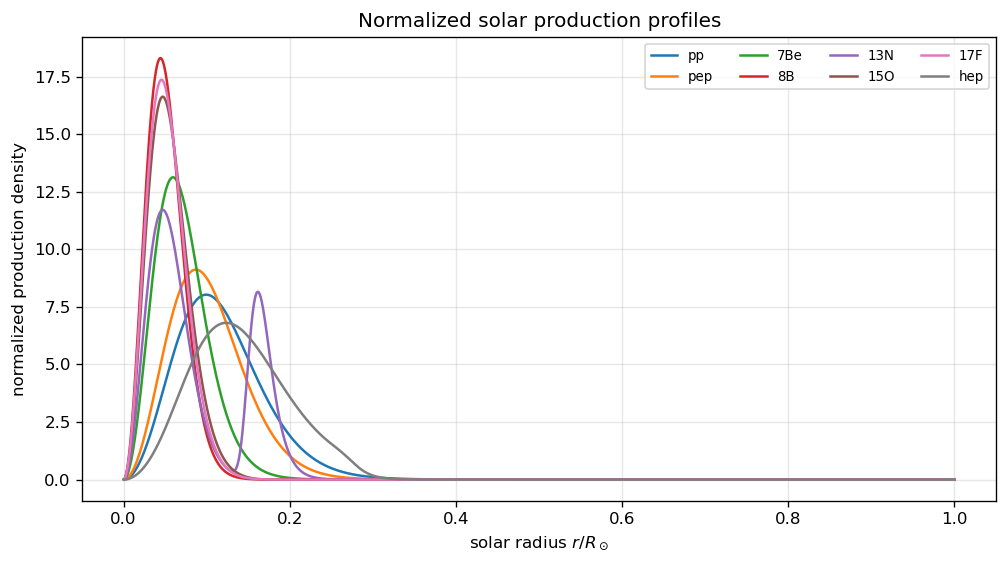

v:\output\diagnostic\solar\diagnostic1_solar_fig4_2_normalized_production_profiles.png
normalized areas: {'pp': 1.0, 'pep': 1.0, '7Be': 0.9999999999999998, '8B': 1.0, '13N': 1.0, '15O': 1.0, '17F': 0.9999999999999999, 'hep': 1.0}


In [28]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
normalized = {}
for source in PLOT_SOURCES:
    normalized[source] = PROFILE.normalized_fraction(source)
    ax.plot(to_numpy(radius), to_numpy(normalized[source]), lw=1.5, label=source)
ax.set_xlabel(r"solar radius $r/R_\odot$")
ax.set_ylabel("normalized production density")
ax.set_title("Normalized solar production profiles")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig4_2_normalized_production_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

norm_areas = {source: float(trapz_area(values, radius).detach().cpu()) for source, values in normalized.items()}
print("normalized areas:", norm_areas)

### 4.3 Cumulative Production and Median Radius

The cumulative integral identifies where each source is produced radially. The median production radius is useful for quickly spotting shifted or malformed profiles.

**Expected results**: high-energy sources such as `8B` and `hep` should be more centrally concentrated than `pp`.

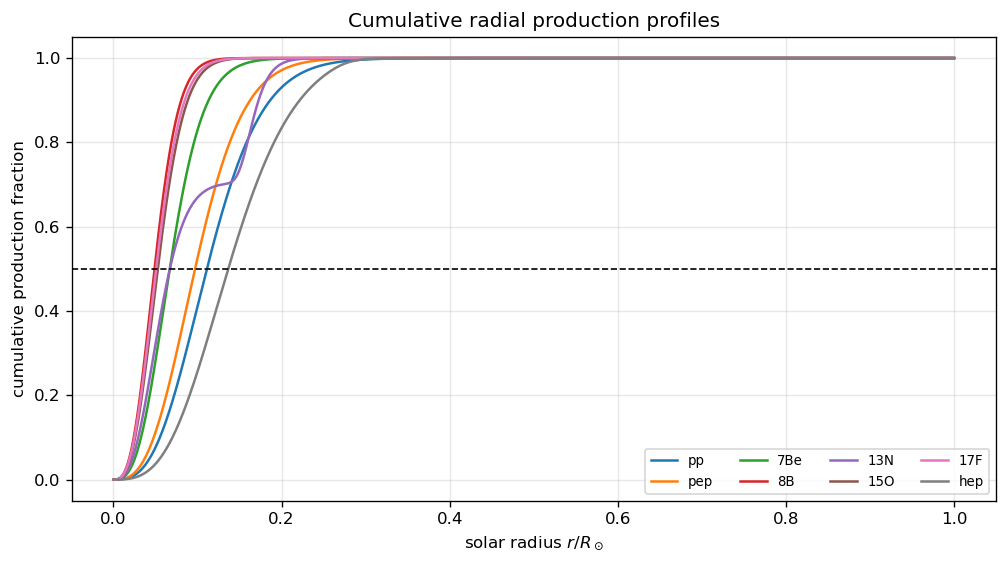

v:\output\diagnostic\solar\diagnostic1_solar_fig4_3_cumulative_production.png


,source,median_radius
3,8B,0.0490
6,17F,0.0510
5,15O,0.0530
2,7Be,0.0670
4,13N,0.0675
1,pep,0.0975
0,pp,0.1115
7,hep,0.1370


In [29]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
median_rows = []
for source in PLOT_SOURCES:
    cdf = cumulative_trapz(normalized[source], radius)
    ax.plot(to_numpy(radius), to_numpy(cdf), lw=1.5, label=source)
    median_rows.append((source, float(median_radius(normalized[source], radius).detach().cpu())))
ax.axhline(0.5, color="black", lw=1.0, ls="--")
ax.set_xlabel(r"solar radius $r/R_\odot$")
ax.set_ylabel("cumulative production fraction")
ax.set_title("Cumulative radial production profiles")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig4_3_cumulative_production.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

median_df = pd.DataFrame(median_rows, columns=["source", "median_radius"])
display(median_df.sort_values("median_radius"))

## 5. Fluxes and Spectra

### 5.1 Total Source Fluxes

The flux table stores one total flux normalization per solar source.

**Expected results**: all loaded fluxes should be positive and span many orders of magnitude between pp and rare high-energy sources.

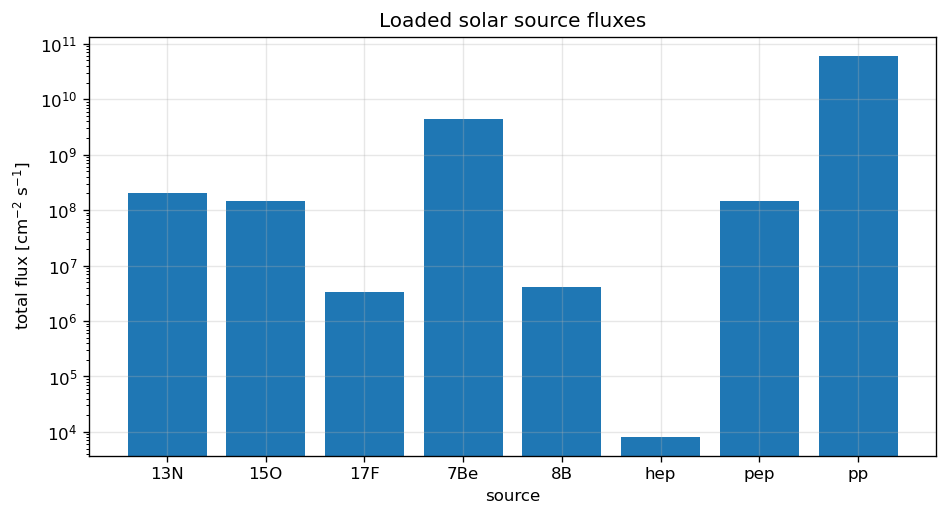

v:\output\diagnostic\solar\diagnostic1_solar_fig5_1_source_fluxes.png


,source,flux
0,13N,2.052000e+08
1,15O,1.447000e+08
2,17F,3.290000e+06
3,7Be,4.429000e+09
4,8B,4.135000e+06
5,hep,8.216000e+03
6,pep,1.451000e+08
7,pp,6.010000e+10


In [30]:
flux_items = sorted((source, float(value.detach().cpu())) for source, value in PROFILE.fluxes.items())
flux_df = pd.DataFrame(flux_items, columns=["source", "flux"])

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.bar(flux_df["source"], flux_df["flux"], color="C0")
ax.set_yscale("log")
ax.set_xlabel("source")
ax.set_ylabel(r"total flux [cm$^{-2}$ s$^{-1}$]")
ax.set_title("Loaded solar source fluxes")
fig.tight_layout()
save_and_show("diagnostic1_solar_fig5_1_source_fluxes.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
display(flux_df)

### 5.2 Tabulated Source Spectra

Several sources have optional energy spectra. This diagnostic checks that the spectrum files are readable and finite.

**Expected results**: spectra should be non-negative over their tabulated support, with source-dependent energy ranges.

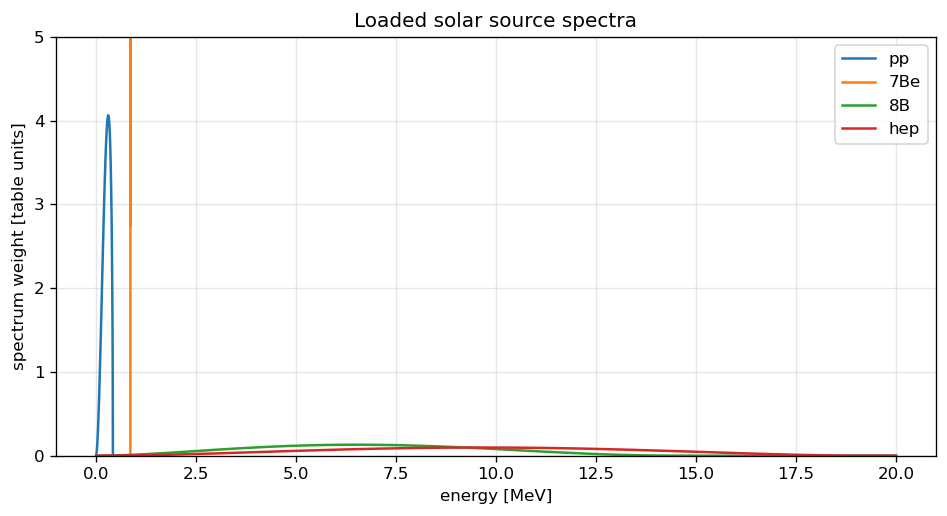

v:\output\diagnostic\solar\diagnostic1_solar_fig5_2_source_spectra.png


,source,n,E_min,E_max,finite
0,pp,84,0.005040,0.42341,True
1,7Be,92,0.859630,0.86873,True
2,8B,123,0.000000,20.00000,True
3,hep,1001,0.018784,20.00000,True


In [39]:
fig, ax = plt.subplots(figsize=(8.0, 4.4))
spectrum_summary = []
for source, path in SPECTRUM_FILES.items():
    spectrum = load_spectrum_csv(path, device=ctx.device, dtype=ctx.dtype)
    energy = spectrum["energy"]
    weight = spectrum["spectrum"]
    ax.plot(to_numpy(energy), to_numpy(weight), lw=1.5, label=source)
    spectrum_summary.append((source, int(energy.numel()), float(energy.min()), float(energy.max()), bool(torch.isfinite(weight).all())))
ax.set_xlabel("energy [MeV]")
ax.set_ylabel("spectrum weight [table units]")
ax.set_title("Loaded solar source spectra")
ax.set_ylim(0,5)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_solar_fig5_2_source_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(pd.DataFrame(spectrum_summary, columns=["source", "n", "E_min", "E_max", "finite"]))

## 6. Solar Coordinates

### 6.1 Radius Fraction and Physical Distance

The profile radius is dimensionless, $\rho=r/R_\odot$. These curves make the conversion to physical radius and radial path length explicit.

**Expected results**: physical radius grows linearly with $\rho$, while the production-to-surface path length decreases linearly to zero at the solar surface.

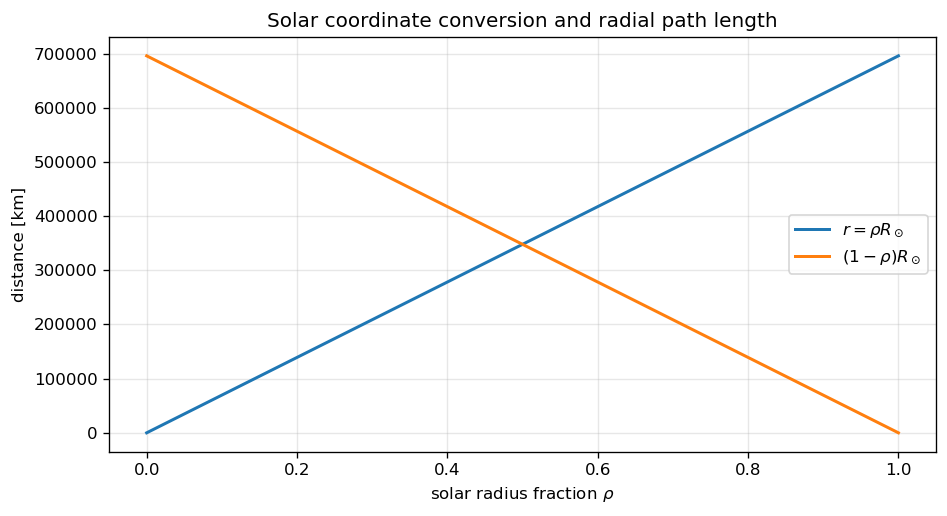

v:\output\diagnostic\solar\diagnostic1_solar_fig6_1_coordinate_conversion.png
R_sun [km]: 695700.0
max rho roundtrip residual: 1.1102230246251565e-16


In [32]:
rho_grid = torch.linspace(0.0, 1.0, 300, device=ctx.device, dtype=ctx.dtype)
radius_km = rho_grid * R_SUN_KM
path_to_surface_km = (1.0 - rho_grid) * R_SUN_KM
rho_roundtrip = radius_km / R_SUN_KM

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(to_numpy(rho_grid), to_numpy(radius_km), lw=1.8, label=r"$r=\rho R_\odot$")
ax.plot(to_numpy(rho_grid), to_numpy(path_to_surface_km), lw=1.8, label=r"$(1-\rho)R_\odot$")
ax.set_xlabel(r"solar radius fraction $\rho$")
ax.set_ylabel("distance [km]")
ax.set_title("Solar coordinate conversion and radial path length")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_solar_fig6_1_coordinate_conversion.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("R_sun [km]:", R_SUN_KM)
print("max rho roundtrip residual:", float(torch.max(torch.abs(rho_roundtrip - rho_grid))))

### 6.2 Profile-Aligned Path Grid

A production point can be connected to the solar surface using the tabulated profile radii above the production radius. This is useful for coherent radial propagation and for debugging shell widths.

**Expected results**: the grid starts at the chosen production radius, ends at $\rho=1$, and its shell widths sum to the production-to-surface path length.

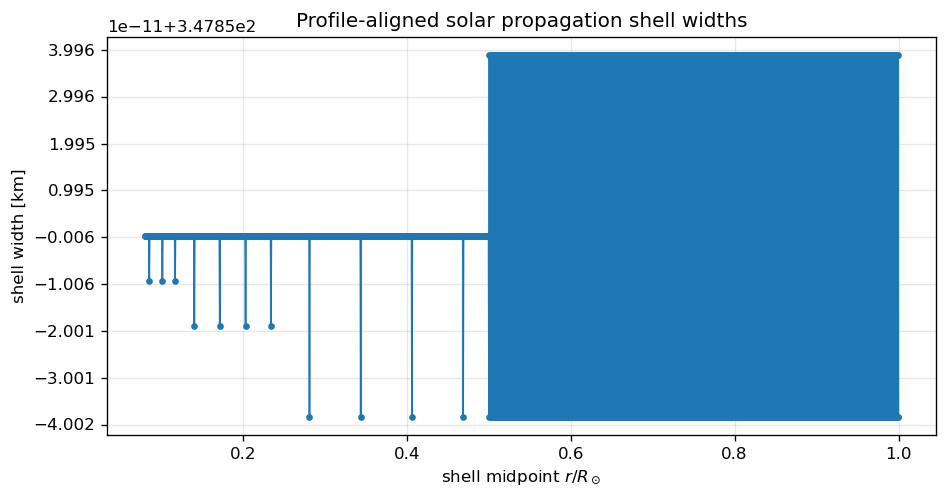

v:\output\diagnostic\solar\diagnostic1_solar_fig6_2_profile_shell_widths.png
rho0: 0.08
path grid points: 1841
first/last grid point: 0.08 1.0
sum shell widths [km]: 640044.0
expected path [km]: 640044.0


In [33]:
rho0 = torch.tensor(0.08, device=ctx.device, dtype=ctx.dtype)
path_grid = torch.cat((rho0.reshape(1), PROFILE.radius[PROFILE.radius > rho0]))
widths_km = torch.diff(path_grid) * R_SUN_KM
midpoints = 0.5 * (path_grid[:-1] + path_grid[1:])
expected_path_km = (1.0 - rho0) * R_SUN_KM

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(to_numpy(midpoints), to_numpy(widths_km), marker=".", lw=1.0)
ax.set_xlabel(r"shell midpoint $r/R_\odot$")
ax.set_ylabel("shell width [km]")
ax.set_title("Profile-aligned solar propagation shell widths")
fig.tight_layout()
save_and_show("diagnostic1_solar_fig6_2_profile_shell_widths.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("rho0:", float(rho0))
print("path grid points:", int(path_grid.numel()))
print("first/last grid point:", float(path_grid[0]), float(path_grid[-1]))
print("sum shell widths [km]:", float(widths_km.sum()))
print("expected path [km]:", float(expected_path_km))

## 7. Adiabatic Matter Mixing

This section visualizes the analytic functions used by `medium.solar.matter_mixing`: the matter-potential ratios `Vk`, the effective splitting `DeltamSqee`, and the matter-modified angles `th12_M` and `th13_M`. The final panel also shows the corresponding adiabatic production weights `T_ei` computed by `medium.solar.probability.Tei`.

**Expected results**: at the solar surface, where density is small, the matter angles should approach their vacuum values. In the dense core, `theta12_M` should move toward the MSW matter-dominated regime for high-energy neutrinos, while the three `T_ei` weights should remain normalized to one.


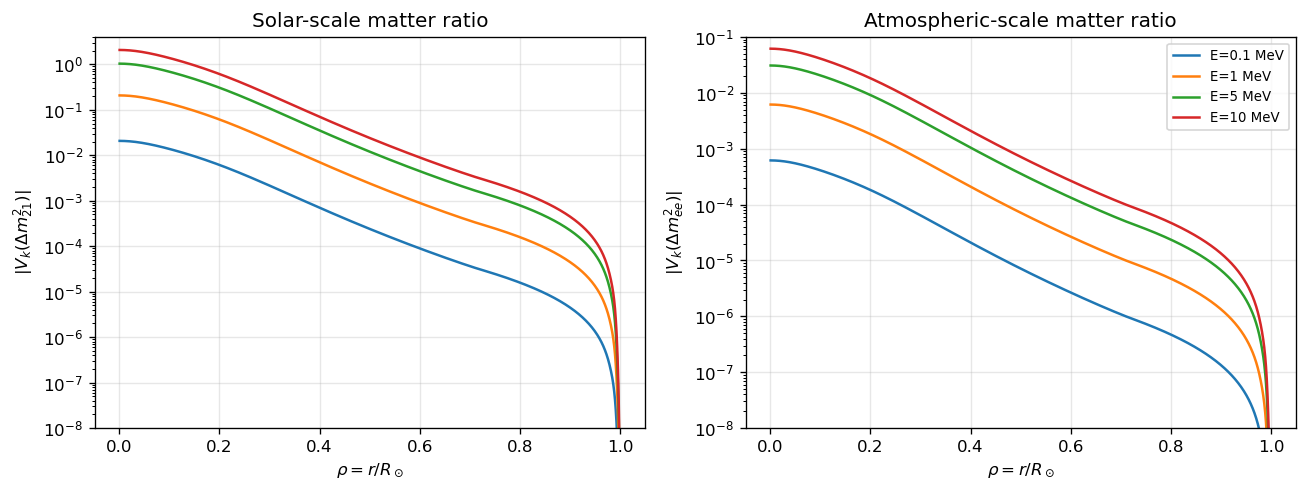

v:\output\diagnostic\solar\diagnostic1_solar_fig7_1_matter_potential_ratios.png
Delta m2_21 [eV2]: 7.41e-05
Delta m2_ee [eV2]: 0.0024885336597853603
max |Vk(dm21)|: 2.074754325629185
max |Vk(dmee)|: 0.06177907014622533


In [37]:
rho = PROFILE.radius
ne = PROFILE.density
energy_grid = MIXING_ENERGIES_MEV[:, None]
density_grid = ne[None, :]

dm21 = OSCILLATION.mass_spectrum.DeltamSq21
dmee = DeltamSqee(OSCILLATION)
vk21 = Vk(dm21, energy_grid, density_grid)
vkee = Vk(dmee, energy_grid, density_grid)

fig, (ax_21, ax_ee) = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True)
for idx, energy in enumerate(MIXING_ENERGIES_MEV):
    label = f"E={float(energy):g} MeV"
    ax_21.semilogy(to_numpy(rho), to_numpy(torch.abs(vk21[idx])), lw=1.5, label=label)
    ax_ee.semilogy(to_numpy(rho), to_numpy(torch.abs(vkee[idx])), lw=1.5, label=label)

ax_21.set_xlabel(r"$\rho=r/R_\odot$")
ax_21.set_ylabel(r"$|V_k(\Delta m^2_{21})|$")
ax_21.set_title(r"Solar-scale matter ratio")
ax_21.grid(True, alpha=0.3)
ax_21.set_ylim(1e-8,4)
ax_ee.set_xlabel(r"$\rho=r/R_\odot$")
ax_ee.set_ylabel(r"$|V_k(\Delta m^2_{ee})|$")
ax_ee.set_title(r"Atmospheric-scale matter ratio")
ax_ee.grid(True, alpha=0.3)
ax_ee.set_ylim(1e-8,1e-1)
ax_ee.legend(fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig7_1_matter_potential_ratios.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("Delta m2_21 [eV2]:", float(dm21))
print("Delta m2_ee [eV2]:", float(dmee))
print("max |Vk(dm21)|:", float(torch.max(torch.abs(vk21))))
print("max |Vk(dmee)|:", float(torch.max(torch.abs(vkee))))


### 7.2 Matter Angles and Adiabatic Weights

The plots below show the radial evolution of the effective mixing angles for several energies and the adiabatic mass-eigenstate weights at 10 MeV.

**Expected results**: `theta12_M` has the strongest visible density dependence in the solar range, especially at high energy. `theta13_M` changes more mildly. The `T_ei` weights should remain positive and sum to one at every radius.


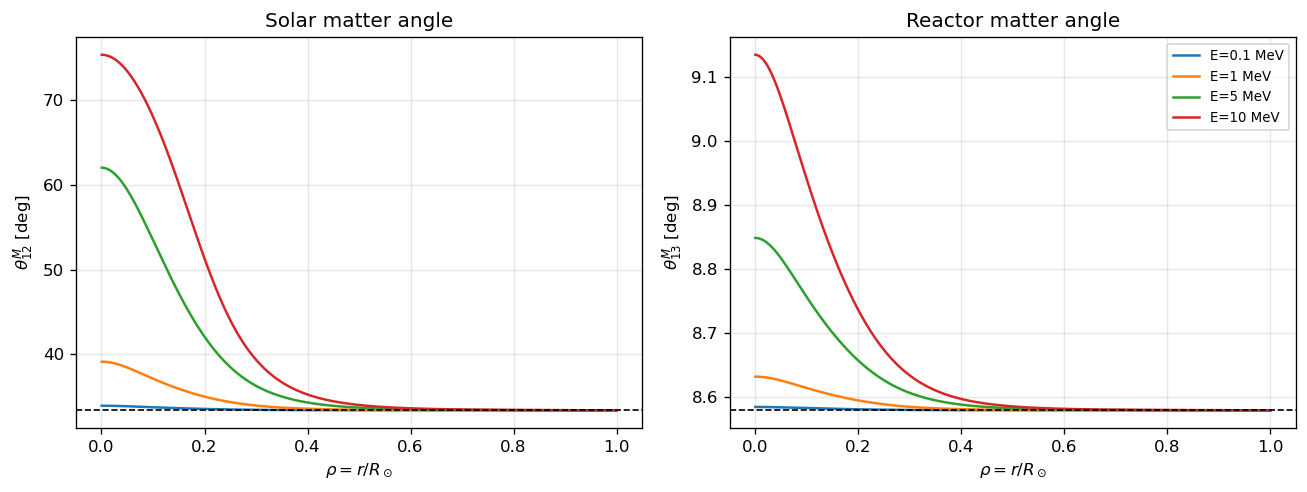

v:\output\diagnostic\solar\diagnostic1_solar_fig7_2_matter_angles.png


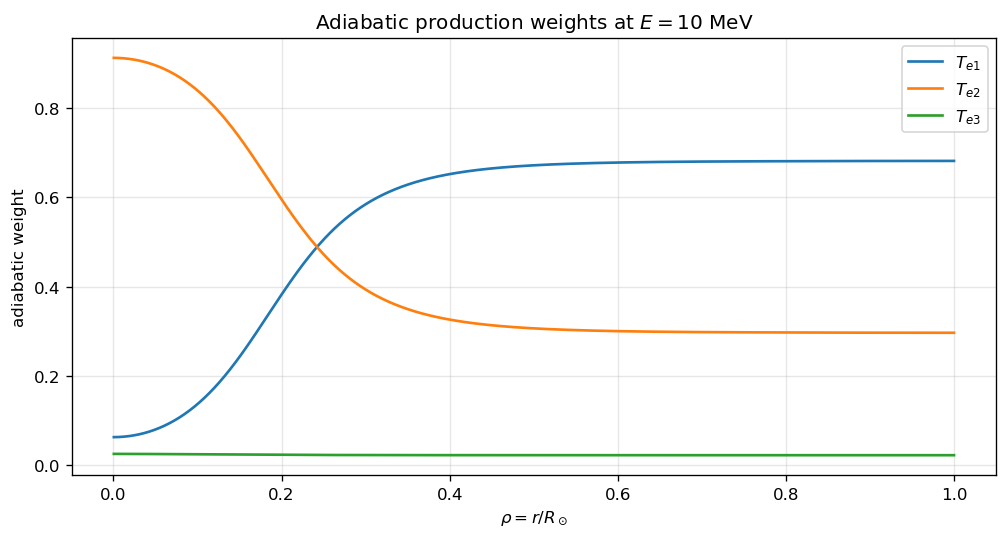

v:\output\diagnostic\solar\diagnostic1_solar_fig7_3_adiabatic_weights.png
vacuum theta12 [deg]: 33.41
vacuum theta13 [deg]: 8.58
max |sum_i T_ei - 1| at 10 MeV: 4.440892098500626e-16


In [35]:
theta12_m = th12_M(OSCILLATION, energy_grid, density_grid)
theta13_m = th13_M(OSCILLATION, energy_grid, density_grid)

fig, (ax_12, ax_13) = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True)
for idx, energy in enumerate(MIXING_ENERGIES_MEV):
    label = f"E={float(energy):g} MeV"
    ax_12.plot(to_numpy(rho), to_numpy(torch.rad2deg(theta12_m[idx])), lw=1.5, label=label)
    ax_13.plot(to_numpy(rho), to_numpy(torch.rad2deg(theta13_m[idx])), lw=1.5, label=label)

vac_theta12_deg = float(torch.rad2deg(OSCILLATION.pmns.params.theta12))
vac_theta13_deg = float(torch.rad2deg(OSCILLATION.pmns.params.theta13))
ax_12.axhline(vac_theta12_deg, color="black", lw=1.0, ls="--")
ax_13.axhline(vac_theta13_deg, color="black", lw=1.0, ls="--")
ax_12.set_xlabel(r"$\rho=r/R_\odot$")
ax_12.set_ylabel(r"$\theta^M_{12}$ [deg]")
ax_12.set_title(r"Solar matter angle")
ax_12.grid(True, alpha=0.3)
ax_13.set_xlabel(r"$\rho=r/R_\odot$")
ax_13.set_ylabel(r"$\theta^M_{13}$ [deg]")
ax_13.set_title(r"Reactor matter angle")
ax_13.grid(True, alpha=0.3)
ax_13.legend(fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig7_2_matter_angles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

weights_10mev = Tei(OSCILLATION, torch.tensor(10.0, device=ctx.device, dtype=ctx.dtype), ne)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for idx, label in enumerate([r"$T_{e1}$", r"$T_{e2}$", r"$T_{e3}$"]):
    ax.plot(to_numpy(rho), to_numpy(weights_10mev[:, idx]), lw=1.6, label=label)
ax.set_xlabel(r"$\rho=r/R_\odot$")
ax.set_ylabel(r"adiabatic weight")
ax.set_title(r"Adiabatic production weights at $E=10$ MeV")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_solar_fig7_3_adiabatic_weights.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

weight_sum_residual = torch.max(torch.abs(weights_10mev.sum(dim=-1) - 1.0))
print("vacuum theta12 [deg]:", vac_theta12_deg)
print("vacuum theta13 [deg]:", vac_theta13_deg)
print("max |sum_i T_ei - 1| at 10 MeV:", float(weight_sum_residual))


## 8. Landau-Zener Correction

This section diagnoses the `medium.solar.landau_zener` module. It visualizes the electron-density gradient, the MSW resonance radius as a function of energy, and the Landau-Zener jump probability returned by `plz`.

**Expected results**: energies without a resonance inside the solar profile should be masked as `NaN` in `r_res` and have `P_LZ=0`. For the standard LMA preset, the resonant high-energy points should also have `P_LZ` numerically consistent with zero because the propagation is extremely adiabatic.


In [ ]:
density_grad = density_gradient(PROFILE)
r_res = resonance_radius(OSCILLATION, LZ_ENERGIES_MEV, PROFILE)
p_lz = plz(OSCILLATION, LZ_ENERGIES_MEV, PROFILE)
finite_res = torch.isfinite(r_res)

fig, (ax_grad, ax_res) = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax_grad.plot(to_numpy(PROFILE.radius), to_numpy(density_grad), lw=1.5)
ax_grad.axhline(0.0, color="black", lw=1.0, ls="--")
ax_grad.set_xlabel(r"$\rho=r/R_\odot$")
ax_grad.set_ylabel(r"$dn_e/d\rho$ [mol cm$^{-3}$]")
ax_grad.set_title("Solar electron-density gradient")
ax_grad.grid(True, alpha=0.3)

ax_res.plot(to_numpy(LZ_ENERGIES_MEV[finite_res]), to_numpy(r_res[finite_res]), lw=1.6)
ax_res.set_xscale("log")
ax_res.set_xlabel("Energy [MeV]")
ax_res.set_ylabel(r"$r_{res}/R_\odot$")
ax_res.set_title(r"$\theta_{12}$ MSW resonance radius")
ax_res.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig8_1_lz_gradient_resonance.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("resonant grid points:", int(finite_res.sum()), "/", int(LZ_ENERGIES_MEV.numel()))
if bool(finite_res.any()):
    print("resonance energy span [MeV]:", float(LZ_ENERGIES_MEV[finite_res][0]), float(LZ_ENERGIES_MEV[finite_res][-1]))
    print("resonance radius span:", float(r_res[finite_res].min()), float(r_res[finite_res].max()))


### 8.2 Jump Probability and Spatial Mask

The Landau-Zener correction only affects production points located inside the resonance radius for a given energy. The first panel shows `P_LZ(E)` with a tiny plotting floor so exact zeros remain visible on a logarithmic axis; the second panel marks the region `rho < r_res(10 MeV)`.

**Expected results**: for the standard LMA preset, `P_LZ` should be zero to float64 precision. At 10 MeV the resonance should lie inside the solar profile, so only production radii below that point would be eligible for an LZ jump if a non-adiabatic scenario were configured.


In [ ]:
plot_floor = torch.full_like(p_lz, torch.finfo(p_lz.dtype).tiny)
p_lz_for_plot = torch.maximum(p_lz, plot_floor)
r_res_10 = resonance_radius(OSCILLATION, torch.tensor(10.0, device=ctx.device, dtype=ctx.dtype), PROFILE)
inside_10 = PROFILE.radius < r_res_10

fig, (ax_p, ax_mask) = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax_p.plot(to_numpy(LZ_ENERGIES_MEV), to_numpy(p_lz_for_plot), lw=1.6)
ax_p.set_xscale("log")
ax_p.set_yscale("log")
ax_p.set_xlabel("Energy [MeV]")
ax_p.set_ylabel(r"$P_{LZ}$")
ax_p.set_title("Landau-Zener jump probability")
ax_p.grid(True, alpha=0.3)

ax_mask.plot(to_numpy(PROFILE.radius), to_numpy(PROFILE.density), lw=1.5, label=r"$n_e(\rho)$")
if bool(torch.isfinite(r_res_10)):
    ax_mask.axvline(float(r_res_10), color="C3", lw=1.4, ls="--", label=r"$r_{res}(10\,\mathrm{MeV})$")
    ax_mask.fill_between(to_numpy(PROFILE.radius), to_numpy(PROFILE.density), where=to_numpy(inside_10), color="C3", alpha=0.18)
ax_mask.set_yscale("log")
ax_mask.set_xlabel(r"$\rho=r/R_\odot$")
ax_mask.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
ax_mask.set_title("Production region eligible for LZ jump at 10 MeV")
ax_mask.grid(True, alpha=0.3)
ax_mask.legend(fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_solar_fig8_2_lz_probability_mask.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("max P_LZ:", float(torch.max(p_lz)))
print("r_res(10 MeV):", float(r_res_10))
print("profile points inside r_res(10 MeV):", int(inside_10.sum()))


## 9. Sun-Earth Distance

The date-resolved distance table supports annual baseline and inverse-square flux diagnostics.

**Expected results**: the distance in AU should oscillate around 1 AU over the year.

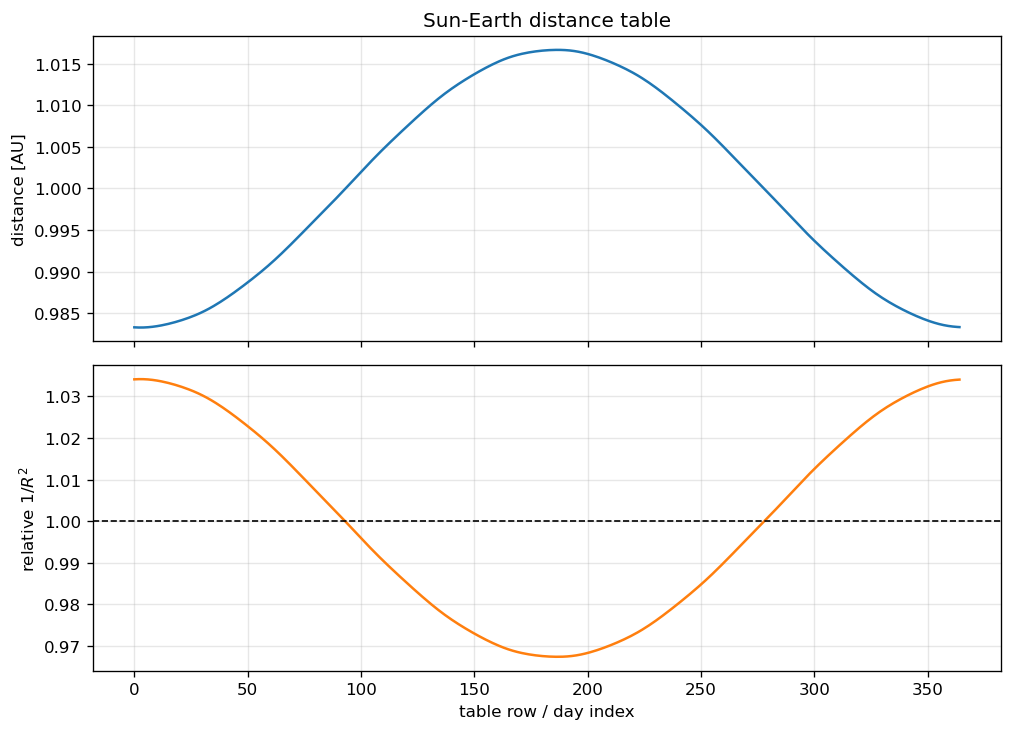

v:\output\diagnostic\solar\diagnostic1_solar_fig8_1_sun_earth_distance.png
distance AU min/max: 0.9833023247402758 1.0166438107623477
relative flux min/max: 0.967411133454942 1.0341287004813984


In [36]:
dates = pd.to_datetime(DISTANCE["date"])
day = np.arange(len(dates))
distance_au = DISTANCE["distance_AU"]
relative_flux = (1.0 / distance_au**2)
relative_flux = relative_flux / torch.mean(relative_flux)

fig, (ax_d, ax_f) = plt.subplots(2, 1, figsize=(8.5, 6.2), sharex=True)
ax_d.plot(day, to_numpy(distance_au), lw=1.5)
ax_d.set_ylabel("distance [AU]")
ax_d.set_title("Sun-Earth distance table")
ax_f.plot(day, to_numpy(relative_flux), lw=1.5, color="C1")
ax_f.axhline(1.0, color="black", lw=1.0, ls="--")
ax_f.set_xlabel("table row / day index")
ax_f.set_ylabel(r"relative $1/R^2$")
fig.tight_layout()
save_and_show("diagnostic1_solar_fig9_1_sun_earth_distance.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("distance AU min/max:", float(distance_au.min()), float(distance_au.max()))
print("relative flux min/max:", float(relative_flux.min()), float(relative_flux.max()))

## 10. Summary

The solar I/O layer converts the packaged solar CSV tables into torch tensors on the requested device and dtype. The density conversion from log scale, source fraction extraction, total flux loading, spectra loading, and Sun-Earth distance parsing are the main failure points covered by the associated pytest files.

The `SolarProfile` layer adds interpolation, source selection, flux lookup, and normalized production profiles. The diagnostics show that the default profile is finite and positive, production profiles normalize correctly, central sources are visibly concentrated in the core, and the packaged spectra and orbital-distance tables are readable for downstream solar probability and flux calculations.